## Option 2A: Traffic Jam Simulator (Physics)
### Real-world context: 
Cities waste billions on traffic congestion. Better prediction models help optimize traffic lights and reduce jams.

### Problem Statement:
Build a 1D highway simulation using Metropolis MCMC where cars maintain safe
distances from neighbors. Start from one slow car and observe how traffic jams form and
spread.

### Hints - 

What to include in your notebook:
1. Create 1D array: 50 car positions (car #25 starts slow)
2. Energy function: penalize cars too close or too far from ideal spacing
3. Metropolis moves: try moving each car ±1 position randomly
4. Plot 1: car positions vs time steps (visualize jam spreading)
5. Plot 2: highway snapshots at 5 different time points
6. Plot 3: jam size (cars within 3 spaces) vs time
7. Brief analysis: When does jam form? How does it grow?


Submit: One .ipynb file with your solution (mention “Problem 2A: Traffic Jam
Simulator” at the top)


In [146]:
import numpy as np                  # importing numpy for various mathematical operations
import matplotlib.pyplot as plt     # importing matplotlip.pyplot for visualizing our data

np.random.seed(0)

In [147]:
road_length = 100                   # number of discreet cells on the road
n_cars = 50                         # total number of cars on the road at a time
timesteps = 500                     # number of times we will do the monte carlo loop
ideal_gap = road_length / n_cars    # equillibrium space that has the minimal energy for the system

slow_car_index = 24                 # the 25th car will be slowed to see traffic
slow_factor = 0.3                   # Its forward motion is cancelled frequently, causing traffic to erupt

In [148]:
# creating the road of length 'road_length' with all the 'n_cars' at equidistances from each other
positions = np.linspace(0, road_length, n_cars, dtype=int, endpoint=False)
positions = positions % road_length

In [149]:
def compute_energy(positions, ideal_gap):
    # this function calculates the energey of a 'road' state
    # it actually sets that the last car if infront of the first car
    # the road behaves like a ring circular road
    
    positions = np.sort(positions)
    gaps = np.diff(positions)
    ring_gap = road_length - positions[-1] + positions[0]
    gaps = np.append(gaps, ring_gap)

    return np.sum((gaps - ideal_gap)**2)


In [150]:
def metropolis_step(positions, beta=1.0):
    positions = positions.copy()
    current_E = compute_energy(positions, ideal_gap)

    for i in range(n_cars):
        car = i

        # the car will either move up a step or stay still with equal probability
        move = np.random.choice([0, 1])

        # the slow car will move forward less frequently
        if car == slow_car_index:
            if move == 1 and np.random.rand() < 0.7:  
                continue

        new_positions = positions.copy()
        new_positions[car] = (new_positions[car] + move) % road_length  # wrapping the edges so that the car at the edge will move to the beggining
        
        # Make sure that no car is occupying the same position
        if len(np.unique(new_positions)) < n_cars:
            continue

        new_E = compute_energy(new_positions, ideal_gap)

        # we will calculating the energy difference between this road state and the original one
        dE = new_E - current_E

        # if the system is lossing energy or maintaining the same energy level we will accept the state
        # else only accepting the new state occasionally
        if dE <= 0 or np.random.rand() < np.exp(-beta * dE):
            positions = new_positions
            current_E = new_E

    return positions


In [151]:
positions_history = np.zeros((timesteps, n_cars), dtype=int)    # creating a 2D array of road states for further evaluations and visualizations
positions_history[0] = positions                                # storing the initial road state in it

for t in range(1, timesteps):
    positions = metropolis_step(positions)                      # using the metropolis function
    positions_history[t] = np.copy(positions)                   # storing the road states in the above array

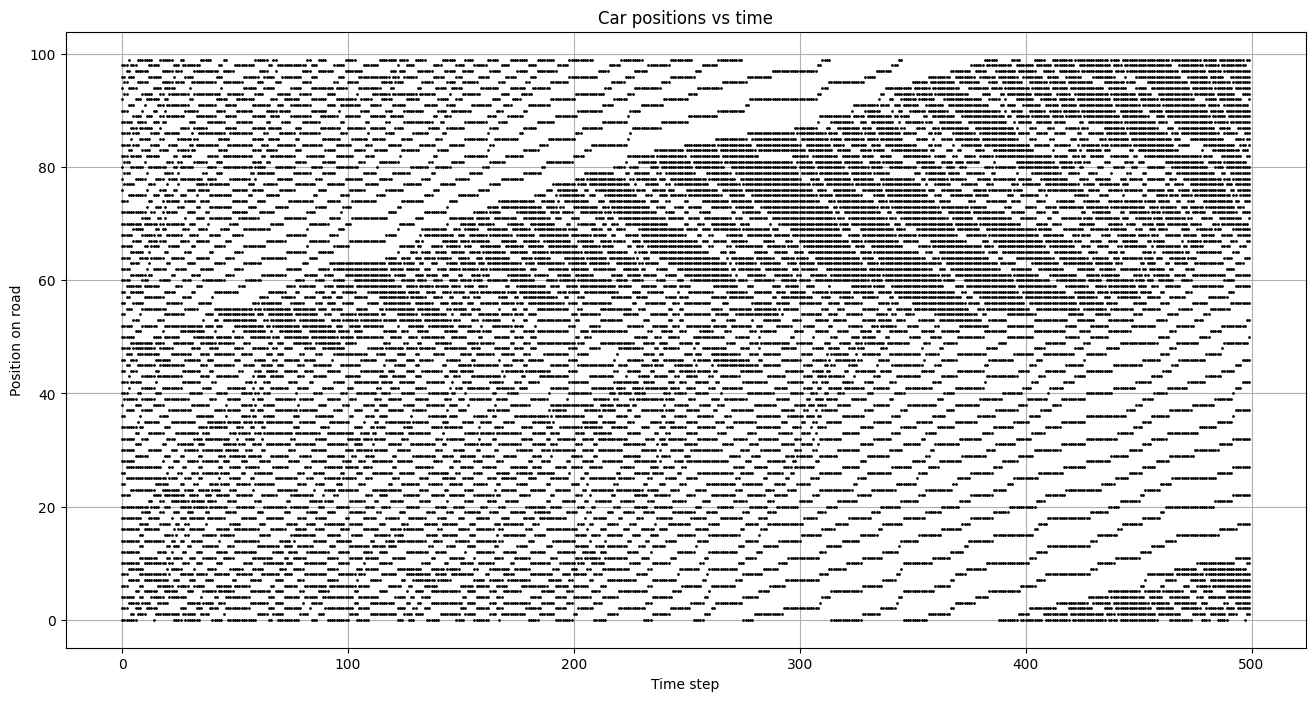

In [152]:
# creating the car position vs time graph
plt.figure(figsize=(16, 8))
for i in range(n_cars):
    plt.plot(range(timesteps), positions_history[:, i], '.', color="black", markersize=2)
plt.xlabel("Time step")
plt.ylabel("Position on road")
plt.title("Car positions vs time")
plt.grid(True)
plt.show()


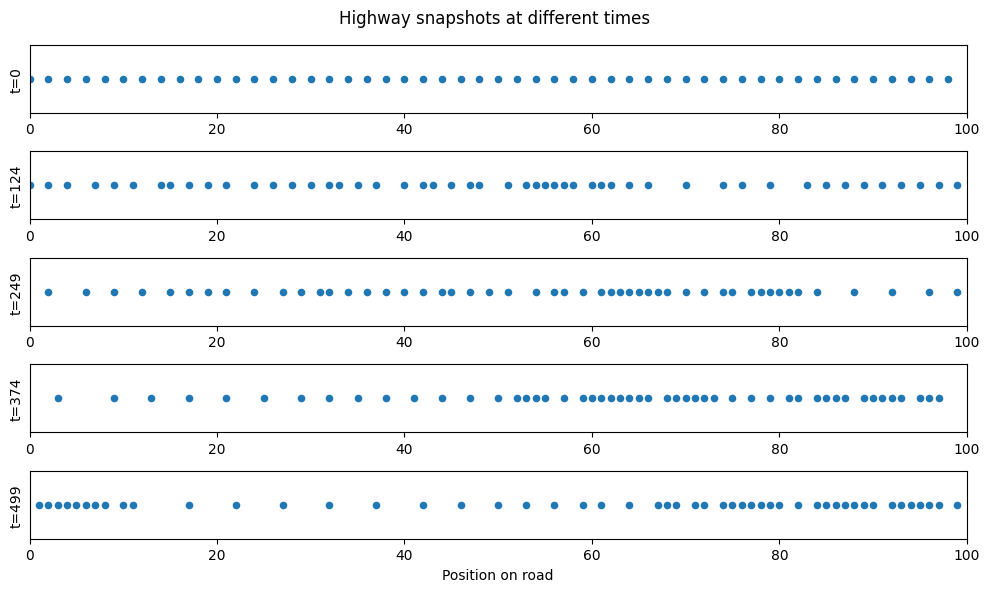

In [153]:
# creating the snapshots at 5 equidistance time
snapshot_times = np.linspace(0, timesteps-1, 5, dtype=int)

plt.figure(figsize=(10, 6))
for idx, t in enumerate(snapshot_times, 1):
    plt.subplot(5, 1, idx)
    plt.scatter(positions_history[t], np.zeros(n_cars), s=20)
    plt.xlim(0, road_length)
    plt.yticks([])
    plt.ylabel(f"t={t}")
plt.xlabel("Position on road")
plt.suptitle("Highway snapshots at different times")
plt.tight_layout()
plt.show()


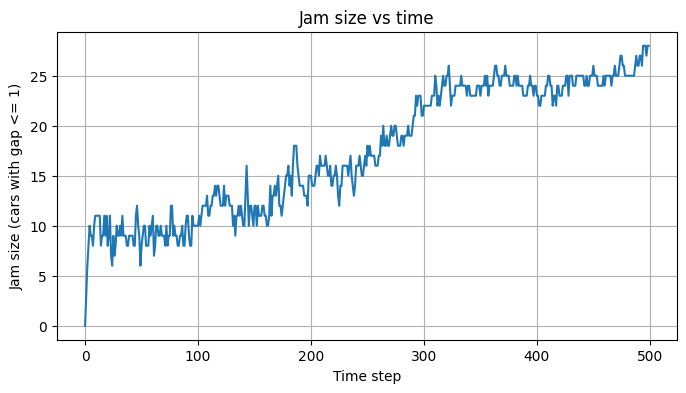

In [154]:
def jam_size(positions, threshold=1):
    pos = np.sort(positions)
    gaps = np.diff(pos)
    ring_gap = road_length - pos[-1] + pos[0]
    gaps = np.append(gaps, ring_gap)
    return np.sum(gaps <= threshold)

jam_sizes = np.zeros(timesteps)     # creating an array for storing jam data
for t in range(timesteps):
    jam_sizes[t] = jam_size(positions_history[t]) # storing the data in 'jam_sizes'

plt.figure(figsize=(8, 4))
plt.plot(range(timesteps), jam_sizes)
plt.xlabel("Time step")
plt.ylabel("Jam size (cars with gap <= 1)")
plt.title("Jam size vs time")
plt.grid(True)
plt.show()


The jam does not form exactly at the slow car’s initial position because jam develops behind the slow vehicle and propagates backward along the ring road. The traffic jam forms near postion ~60 and grows as following vehicle compress due to reduced forward motion. The motion of cars go forward but the jam propagates backward.